<div style="display: flex; background-color: RGB(255,114,0);">
  <h1 style="margin: auto; padding: 30px; color: white;">DÉTECTION DE FAUX BILLETS</h1>
</di>


# OBJECTIF DE CE NOTEBOOK

Ce notebook s’inscrit dans le cadre d’une mission confiée par l’Organisation nationale de lutte contre le faux-monnayage (ONCFM).

L’objectif est de concevoir et d’évaluer un algorithme de détection automatique de faux billets, à partir de mesures physiques réalisées sur des billets de banque.

Plus précisément, ce travail vise à :

- explorer et préparer un jeu de données contenant des billets authentiques et contrefaits ;

- analyser et traiter les valeurs manquantes afin de garantir la qualité des données ;

- tester et comparer plusieurs approches de machine learning, supervisées et non supervisées ;

- sélectionner un modèle de classification pertinent pour un usage opérationnel ;

- mettre en œuvre une chaîne de prédiction complète, depuis les données brutes jusqu’à la décision finale (VRAI / FAUX).

Ce notebook constitue ainsi la base analytique et méthodologique d’un outil d’aide à la décision, destiné à prioriser les contrôles humains et à renforcer l’efficacité de la lutte contre le faux-monnayage.

<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 1 – LES DONNÉES</h2>
</div>

<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">1.1 – Importation des librairies</h3>
</di>

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import os
os.environ["OMP_NUM_THREADS"] = "8"


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des données</h3>
</div>

In [7]:
#Importation du fichier billets.csv
df = pd.read_csv("billets.csv", sep=";")

<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.3 - Analyse exploratoire du fichier billets.csv</h3>
</div>



In [9]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s)".format(df.shape[0]))
print("\nLe tableau comporte {} colonne(s)".format(df.shape[1]))

Le tableau comporte 1500 observation(s)

Le tableau comporte 7 colonne(s)


In [10]:
# Affichage des premières lignes du dataset billets.csv

print("Les 5 premières lignes de la table BILLETS se présentent ainsi :\n")
display(df.head())

Les 5 premières lignes de la table BILLETS se présentent ainsi :



,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [11]:
# Informations générales sur le fichier billet.csv

print("\nInformations sur la table BILLETS :\n")
df.info()


Informations sur la table BILLETS :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [12]:
# Résumé statistique global (centrales & dispersion)
df.describe()


,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [13]:
# Valeurs manquantes
print("Valeurs manquantes :\n")
print(df.isnull().sum())

Valeurs manquantes :

is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64


La seule variable comportant des valeurs manquantes est margin_low avec 37 valeurs manquantes sur 1500, soit ≈2.5% du jeu de données.
Cela justifie un traitement spécifique (ex. régression) sans supprimer les lignes.

In [15]:
# Détection des doublons
print("Lignes dupliquées :")
print(df.duplicated().sum())

Lignes dupliquées :
0


In [16]:
# Nombre de billets uniques
print("Nombre total de billets :", df.shape[0])

# Répartition des billets par catégorie (vrais / faux)
print("\nRépartition des billets par catégorie (vrais / faux) :")
print(df['is_genuine'].value_counts())

Nombre total de billets : 1500

Répartition des billets par catégorie (vrais / faux) :
is_genuine
True     1000
False     500
Name: count, dtype: int64


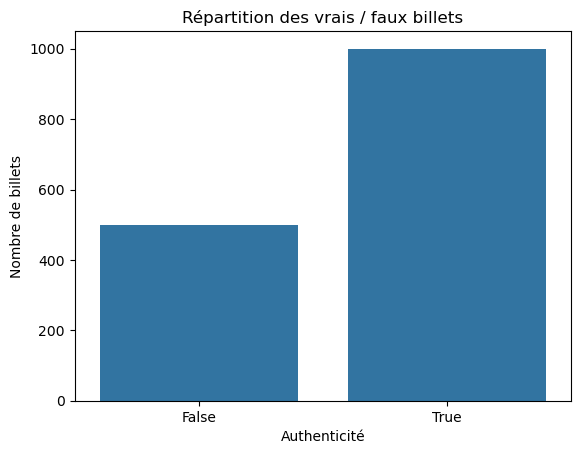

In [17]:
sns.countplot(data=df, x='is_genuine')
plt.title("Répartition des vrais / faux billets")
plt.xlabel("Authenticité")
plt.ylabel("Nombre de billets")
plt.show()


<div style="border: 1px solid RGB(51,165,182);">
  <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">1.4 - Analyse  exploratoire comparative</h3>
</div>


### Statistiques descriptives par classe

In [20]:
df.groupby("is_genuine").describe()


diagonal                                                         \
              count       mean       std     min     25%     50%       75%   
is_genuine                                                                   
False         500.0  171.90116  0.306861  171.04  171.69  171.91  172.0925   
True         1000.0  171.98708  0.300441  171.04  171.79  171.99  172.2000   

                   height_left             ... margin_up        length  \
               max       count       mean  ...       75%   max   count   
is_genuine                                 ...                           
False       173.01       500.0  104.19034  ...    3.4725  3.91   500.0   
True        172.92      1000.0  103.94913  ...    3.1800  3.74  1000.0   

                                                                          
                 mean       std     min     25%      50%     75%     max  
is_genuine                                                                
False       111.63064  0.615543  109.49  111.20  111.630  112.03  113.85  
True        113.20243  0.359552  111.76  112.95  113.205  113.46  114.44  

[2 rows x 48 columns]

### Matrice de scatter plots pairwise (pairplot)

Nous utilisons ici un pairplot pour explorer visuellement les relations entre les différentes variables numériques du dataset (diagonal, height_left, height_right, margin_low, margin_up, length) et leur capacité à distinguer les vrais des faux billets (is_genuine).

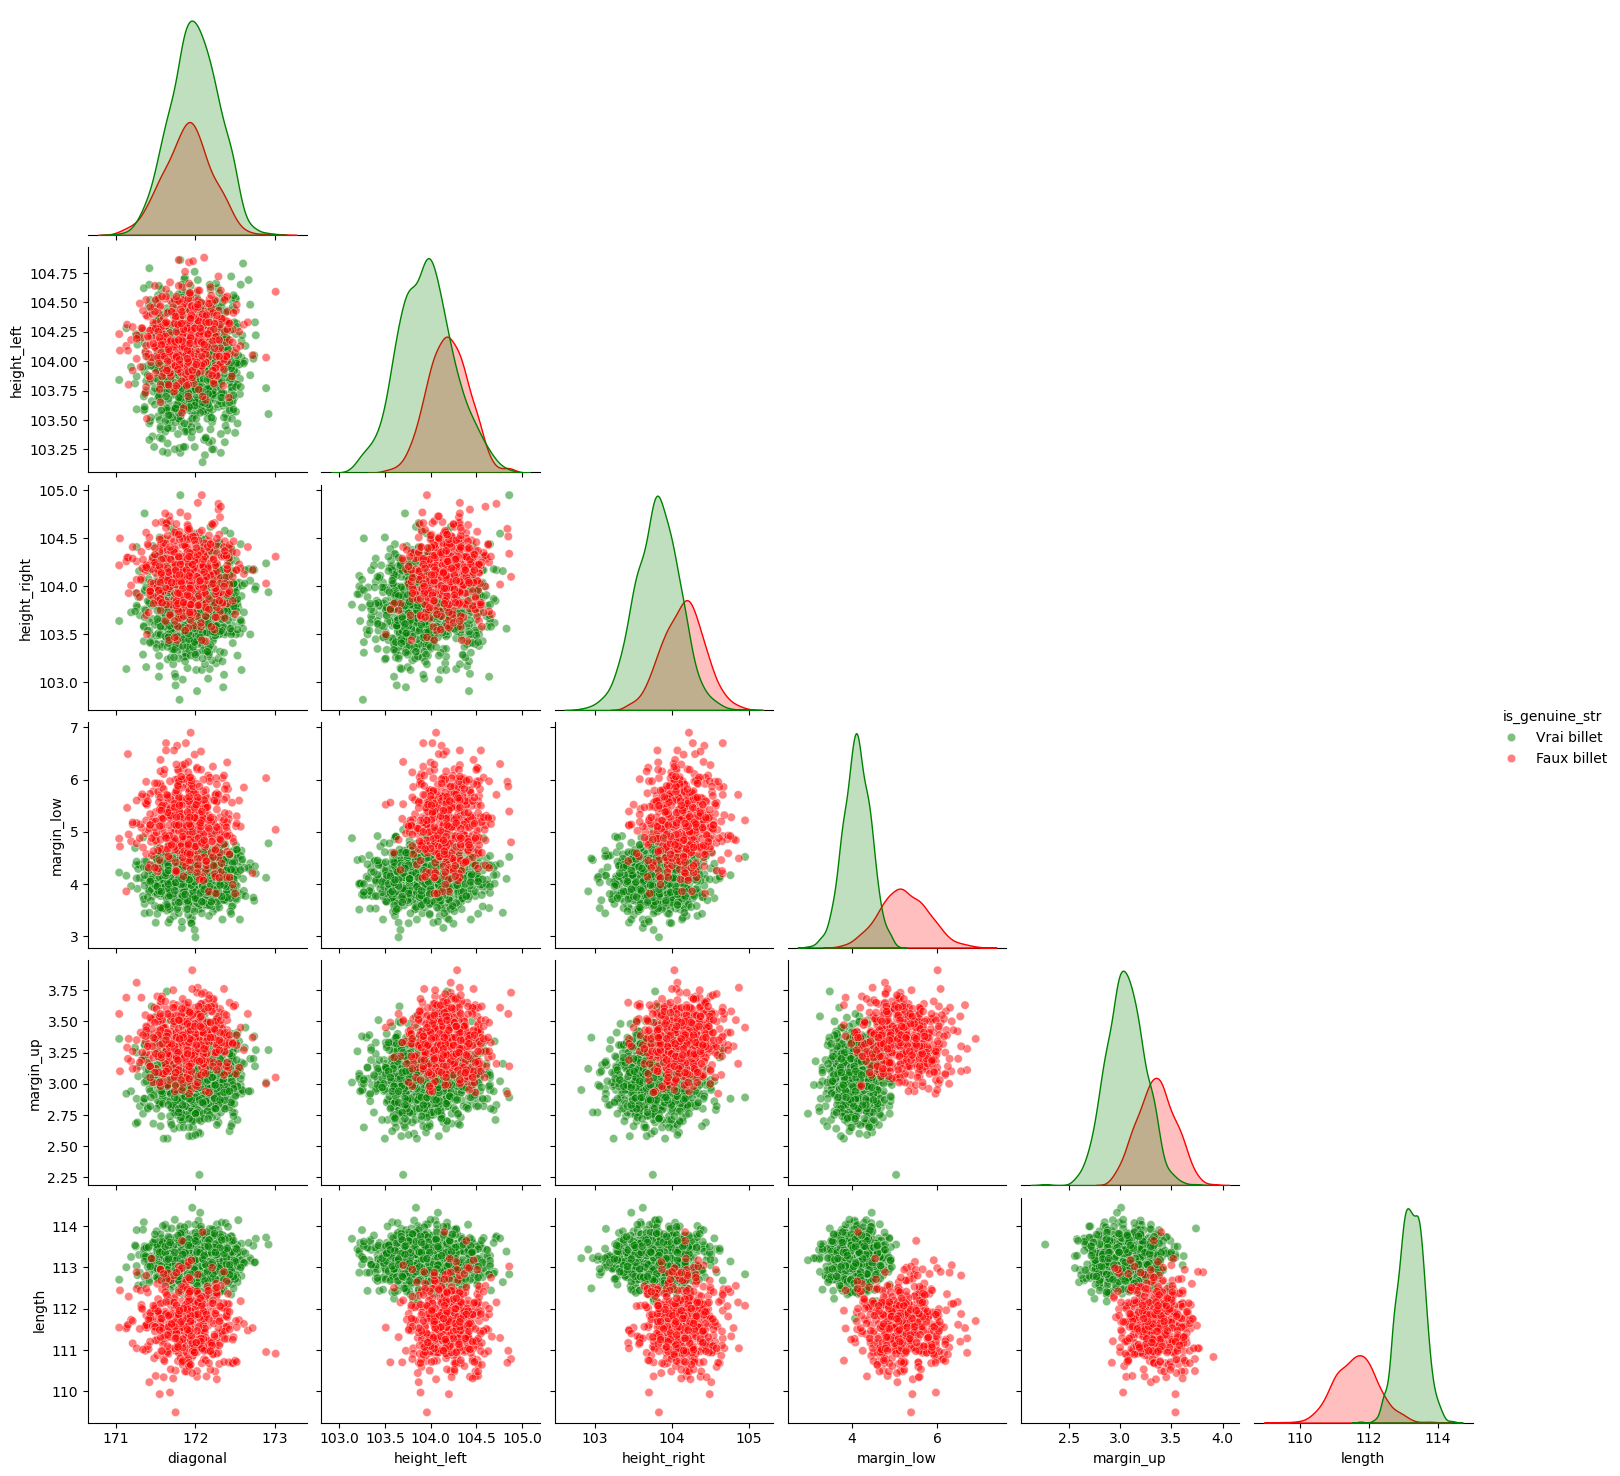

In [23]:
# Convertir la variable cible en chaîne de caractères pour une légende plus lisible
df['is_genuine_str'] = df['is_genuine'].map({True: "Vrai billet", False: "Faux billet"})

# Création du pairplot
sns.pairplot(df.drop(columns=['is_genuine']), 
             hue="is_genuine_str", 
             corner=True,  # évite la duplication des graphiques
             palette={"Vrai billet": "green", "Faux billet": "red"},
             plot_kws={'alpha': 0.5})  # rend les points semi-transparents


#### Visualisation pairplot : relations entre variables et détection de critères discriminants


##### Lecture du pairplot

- **Sur la diagonale** : chaque graphique montre la distribution d’une variable, séparée par classe (`Vrai billet` en vert, `Faux billet` en rouge).
    - ➕ Lorsque les courbes sont bien distinctes, cela indique que la variable est probablement discriminante.
    - ➖ Si les distributions se superposent fortement, la variable est moins utile pour séparer les classes.

- **Hors diagonale** : les nuages de points représentent les relations entre deux variables.
    - Si les classes (`True`/`False`) forment des **groupes visuellement distincts**, c’est un bon indicateur pour la modélisation.
    - Si les points sont très alignés en diagonale, cela révèle une **corrélation forte** entre variables (ex. : `height_left` et `height_right`).

##### Interprétations principales :

- La variable `length` est **nettement plus élevée pour les vrais billets** → bon critère discriminant.
- La variable `margin_low` est **plus élevée pour les faux billets**.
- Les variables `height_left` et `height_right` sont **fortement corrélées**, ce qui peut introduire de la redondance dans les modèles.
- D’autres variables comme `margin_up` ou `diagonal` montrent des **différences modérées** entre classes.

##### Conclusion :

Le pairplot confirme visuellement certaines tendances observées dans l’analyse statistique, et permet d’identifier des variables clés à retenir pour la suite du projet : `length`, `margin_low`, `margin_up`.  
Certaines variables très corrélées pourraient être retirées ou réduites en dimension si besoin (ex. : ACP).


<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 2 – TRAITEMENT DES DONNÉES MANQUANTES ET DÉCISION MÉTHODOLOGIQUE</h2>
</div>


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">2.1 – Visualisation et préparation de la variable cible <code>margin_low</code></h3>
</div>


In [27]:
# Vérification des valeurs manquantes
print("Nombre de valeurs manquantes dans margin_low :", df["margin_low"].isna().sum())


Nombre de valeurs manquantes dans margin_low : 37


In [28]:
# On vérifie la répartition des valeurs manquantes par type de billet
df[df['margin_low'].isna()]['is_genuine'].value_counts()


is_genuine
True     29
False     8
Name: count, dtype: int64

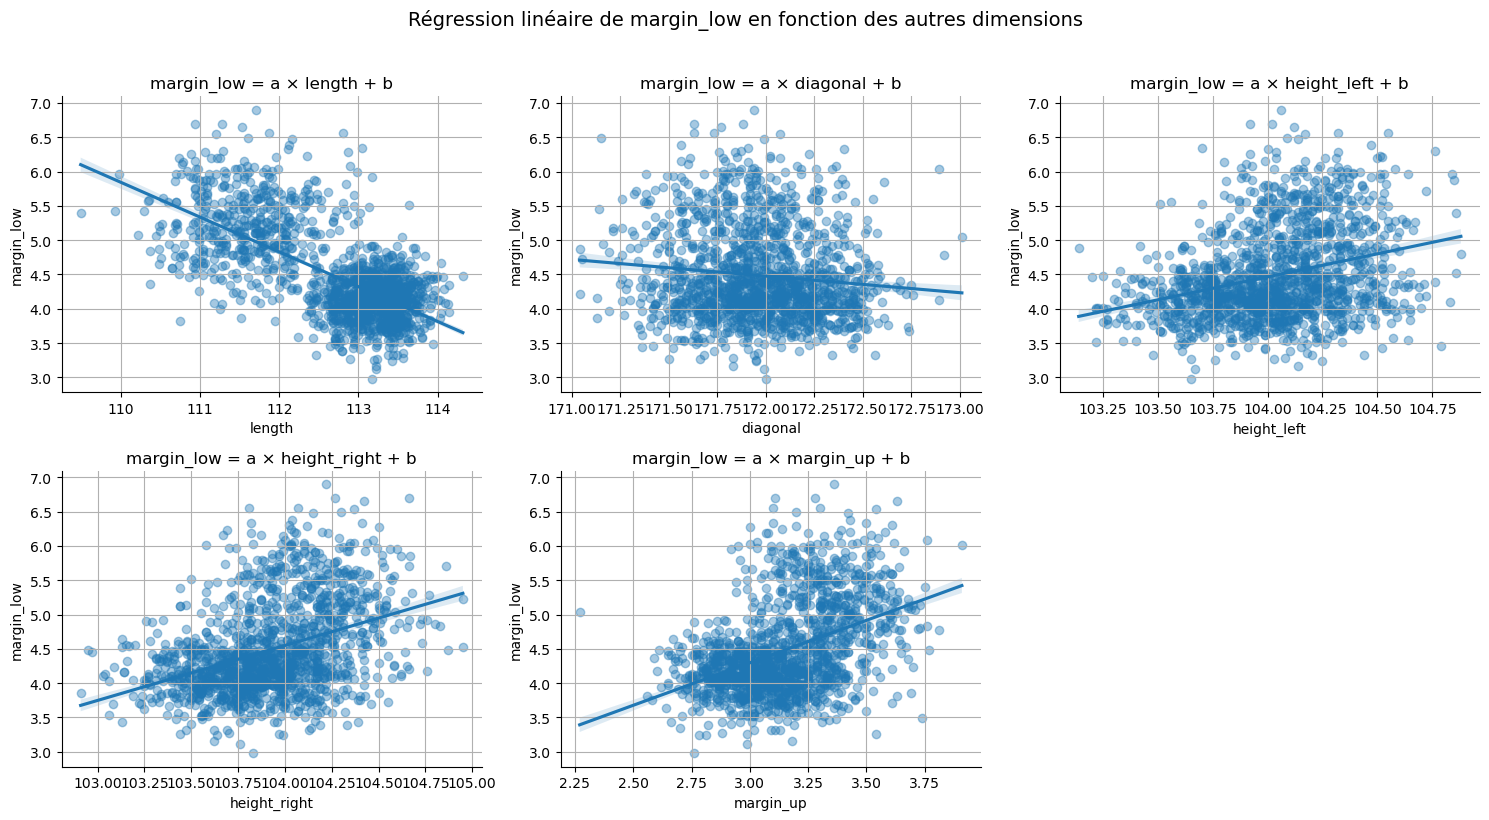

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['length', 'diagonal', 'height_left', 'height_right', 'margin_up']
n = len(variables)

rows = 2
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()  # aplatit la grille pour un accès indexé simple

for i, var in enumerate(variables):
    sns.regplot(x=df[var], y=df['margin_low'], ax=axes[i], scatter_kws={'alpha':0.4})
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("margin_low")
    axes[i].set_title(f"margin_low = a × {var} + b")
    axes[i].grid(True)
    sns.despine(ax=axes[i])

# Masquer les axes inutilisés (s'il y en a)
for j in range(n, rows * cols):
    fig.delaxes(axes[j])

fig.suptitle("Régression linéaire de margin_low en fonction des autres dimensions", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


> #### Régression linéaire de `margin_low` en fonction des autres dimensions  
>
> Ce graphique permet de visualiser la relation entre la variable cible `margin_low` (marge basse du billet) et les autres dimensions mesurées (`length`, `diagonal`, etc.).  
>
> Chaque sous-graphique trace une **droite de régression linéaire**, permettant d’observer :  
> – Le **sens** de la relation (positive ou négative),  
> – La **force visuelle** de la corrélation (pente nette ou nuage diffus).  
>
> **Principales observations visuelles :**  
>
> - 📉 `length` : relation clairement **négative**. Plus le billet est long, plus la marge basse tend à diminuer. C’est la relation la plus marquée visuellement.  
> - 📈 `height_left`, `height_right`, `margin_up` : relations **légèrement positives**, mais nuages plus dispersés (corrélations modérées).  
> - ➖ `diagonal` : relation modérée, plus difficile à interpréter visuellement.  
>
> ➡️ **Conclusion** : Ces observations confortent le choix d’un **modèle de régression linéaire multiple** pour prédire les valeurs manquantes de `margin_low`.  
> La variable `length`, en particulier, apparaît comme un **bon prédicteur**.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">2.2 – Construction du modèle de régression linéaire</h3>
</div>

#### Objectif

Nous allons construire un **modèle de régression linéaire multiple** pour estimer les **valeurs manquantes de la variable `margin_low`**, en s’appuyant sur les autres dimensions physiques des billets.

#### Préparation des données

Avant d'entraîner le modèle :

- on **sépare les lignes complètes** (sans valeur manquante pour `margin_low`), qui serviront à l'entraînement ;
- on définit les **variables explicatives (`X_train`)** en supprimant :
  - `margin_low` (c’est la variable cible à prédire),
  - `is_genuine` (booléen, non pertinent ici),
  - `is_genuine_str` (catégorielle, non adaptée à la régression linéaire) ;
- cela nous laisse uniquement des **variables numériques continues** (`diagonal`, `length`, etc.), bien adaptées à un modèle linéaire.

On vérifie ensuite les dimensions de nos matrices `X_train` (features) et `y_train` (cible).

#### Pourquoi ne pas utiliser uniquement la variable `length` ?

La visualisation exploratoire (section 2.1) a révélé une **forte relation linéaire négative entre `margin_low` et `length`**, ce qui pourrait justifier un modèle simple.

> Cependant, se limiter à une seule variable serait **réducteur**.

En combinant plusieurs dimensions du billet (`diagonal`, `height_left`, `margin_up`…), on :
- **peut mieux capturer la variabilité** de la marge basse,
- **réduit l’impact du bruit** ou des valeurs atypiques sur une seule variable,
- **améliore la précision des prédictions**.

> **Conclusion** :  
> Nous construisons donc un **modèle de régression linéaire multiple** en nous appuyant sur toutes les variables pertinentes disponibles.


In [33]:
from sklearn.linear_model import LinearRegression

# Séparer les lignes sans valeurs manquantes sur margin_low (pour l'entraînement)
df_train = df[df['margin_low'].notna()]
df_missing = df[df['margin_low'].isna()]

# Définir X (variables explicatives) et y (variable cible)
# On retire également la colonne 'is_genuine_str' car ce n’est pas une variable numérique
X_train = df_train.drop(columns=['margin_low', 'is_genuine', 'is_genuine_str'])
y_train = df_train['margin_low']

# Vérification des dimensions
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (1463, 5)
y_train shape: (1463,)


In [34]:
print(X_train.columns)


Index(['diagonal', 'height_left', 'height_right', 'margin_up', 'length'], dtype='object')


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">2.3 – Entraînement du modèle et prédiction des valeurs manquantes</h3>
</div>

Nous entraînons maintenant un modèle de **régression linéaire multiple** pour prédire la variable `margin_low`, à partir des autres dimensions du billet (longueur, hauteur, diagonale, etc.).

Une fois entraîné sur les 1 463 lignes complètes, ce modèle est utilisé pour **prédire les 37 valeurs manquantes** de `margin_low`.

On stocke ces valeurs prédites dans une nouvelle colonne (`margin_low_pred`) pour pouvoir comparer ou réintégrer les données par la suite.


In [37]:
# Création et entraînement du modèle de régression linéaire
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Affichage des coefficients
print("Coefficients du modèle :")
for feature, coef in zip(X_train.columns, model_lr.coef_):
    print(f"{feature} : {coef:.4f}")
print(f"\nIntercept : {model_lr.intercept_:.4f}")



Coefficients du modèle :
diagonal : -0.1111
height_left : 0.1841
height_right : 0.2571
margin_up : 0.2562
length : -0.4091

Intercept : 22.9948


#### Résultats du modèle de régression linéaire

Le modèle a appris une relation linéaire entre la variable `margin_low` (cible) et les autres dimensions du billet. Les coefficients estimés sont les suivants :

- `height_left` : +0.18
- `height_right` : +0.26
- `margin_up` : +0.26
- `diagonal` : -0.11
- `length` : -0.41

Cela signifie que `margin_low` augmente légèrement avec la hauteur (`height_left` et `height_right`) ou la `margin_up`, mais diminue quand `diagonal` ou `length` augmentent.

Le modèle est ensuite utilisé pour prédire les 37 valeurs manquantes de `margin_low`. Voici un aperçu des premières valeurs prédites :


In [39]:
# Prédiction des valeurs manquantes
X_missing = df_missing[X_train.columns]
df_missing.loc[:, 'margin_low_pred'] = model_lr.predict(X_missing)

# Aperçu des valeurs prédites
print("\nAperçu des valeurs prédites :")
display(df_missing[['diagonal', 'height_left', 'height_right', 'margin_up', 'length', 'margin_low_pred']].head())



Aperçu des valeurs prédites :


C:\Users\laure\AppData\Local\Temp\ipykernel_13996\604209428.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing.loc[:, 'margin_low_pred'] = model_lr.predict(X_missing)


,diagonal,height_left,height_right,margin_up,length,margin_low_pred
72,171.94,103.89,103.45,3.25,112.79,4.318525
99,171.93,104.07,104.18,3.14,113.08,4.393668
151,172.07,103.80,104.38,3.02,112.93,4.410457
197,171.45,103.66,103.80,3.62,113.27,4.319014
241,171.83,104.14,104.06,3.02,112.36,4.650617


<div style="border: 1px solid RGB(51,165,182);"> <h3 style="margin: auto; padding: 20px; color: RGB(51,165,182);">2.4 – Vérification des hypothèses du modèle de régression linéaire</h3> </div>

### 2.4.1 - Objectif de cette étape

Quand on entraîne un modèle de **régression linéaire**, l’objectif est de prédire une variable cible (`margin_low`) à partir d’autres variables numériques (`diagonal`, `length`, etc.).

Une fois le modèle entraîné, on peut calculer les **valeurs prédites** (`y_pred`) sur les données connues.  
Mais ces prédictions ne sont jamais parfaites : il y a toujours une **différence** entre la **valeur réelle** et la **valeur prédite**.

Cette différence s’appelle un **résidu** :

>résidu = valeur réelle - valeur prédite

Autrement dit, **les résidus mesurent l’erreur du modèle sur chaque observation**.

In [43]:
import seaborn as sns
import scipy.stats as stats

# Prédictions et résidus
y_pred = model_lr.predict(X_train)
residuals = y_train - y_pred

# Dimensions
print("Résidus shape:", residuals.shape)


Résidus shape: (1463,)


#### Analyse des résidus ?

L’analyse des résidus permet de vérifier si les **hypothèses de la régression linéaire** sont respectées.  
Si ces hypothèses ne sont pas vérifiées, cela peut remettre en question la qualité du modèle.

| Hypothèse  | Ce qu’on attend dans les résidus  | Visualisation utilisée  |
|-------------|------------------------------------|----------------------------|
| **Linéarité** | Pas de structure particulière dans le nuage de points | Résidus vs prédictions |
| **Normalité** | Résidus centrés, symétriques, en forme de cloche | Histogramme + QQ-plot |
| **Homoscédasticité** | Variance constante des résidus, pas d’éventail | Résidus vs prédictions |

### 2.4.2 - Linéarité

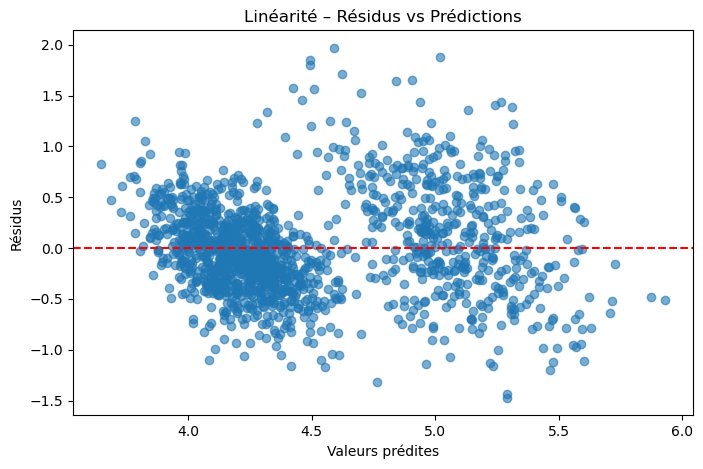

In [46]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Linéarité – Résidus vs Prédictions")
plt.show()


>Le nuage de points des résidus vs. prédictions doit être centré autour de la ligne 0 (en rouge), sans structure particulière ni tendance marquée.
>
>Ici, les résidus sont globalement centrés autour de 0, ce qui va dans le sens d’une relation linéaire acceptable.
Cependant, on observe une structure en deux blocs distincts, suggérant que la relation entre les variables explicatives et margin_low pourrait ne pas être parfaitement linéaire sur l’ensemble du domaine.
>
>Cette observation invite à la prudence quant à l’utilisation de la régression linéaire comme outil d’imputation.

### 2.4.3 - Normalité des résidus

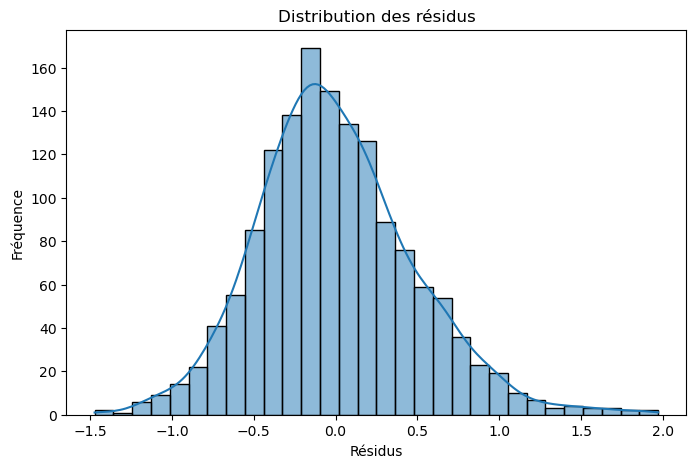

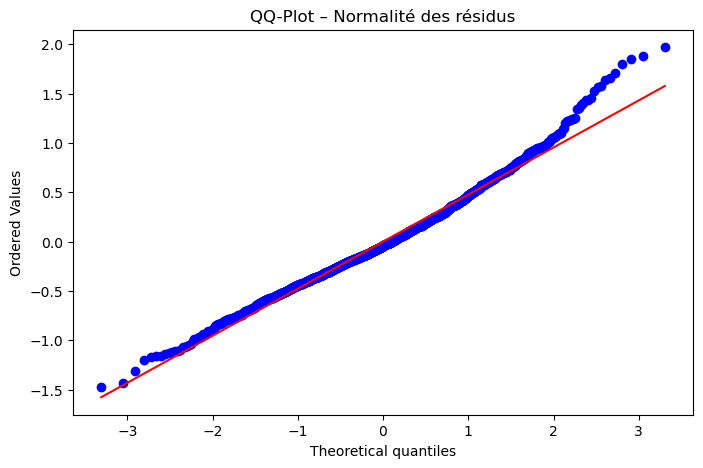

In [49]:
# Histogramme des résidus
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30)
plt.title("Distribution des résidus")
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.show()

# QQ-plot (quantile-quantile plot)
plt.figure(figsize=(8, 5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot – Normalité des résidus")
plt.show()


>La normalité des résidus est importante pour l’interprétation statistique du modèle.
>
>- L’histogramme des résidus présente une forme globalement gaussienne.
>
>- Le QQ-plot montre un bon alignement avec la droite théorique, malgré de légères déviations en queue.
>  
>Cette hypothèse est raisonnablement respectée, sans être parfaitement idéale.

### 2.4.4 - Homoscédasticité (variance constante des résidus)

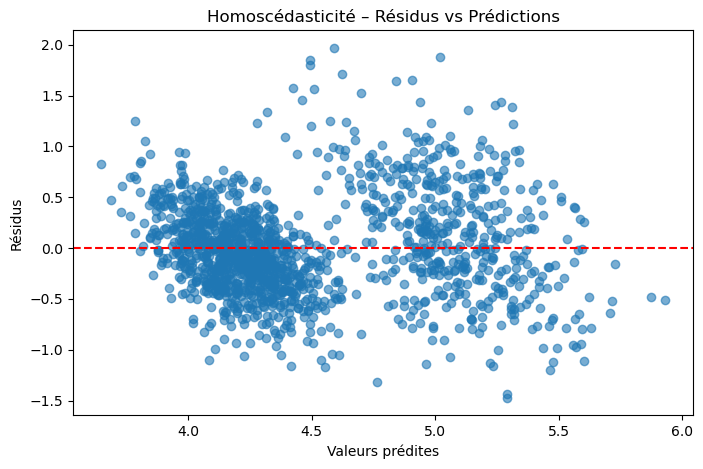

In [52]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Homoscédasticité – Résidus vs Prédictions")
plt.show()


>Les résidus doivent avoir une variance constante quel que soit le niveau de la prédiction (absence de “cône” ou “entonnoir”).
>
>Visuellement :
>- la dispersion des résidus n’est pas totalement uniforme,
>- on observe une concentration marquée pour les valeurs prédites les plus faibles,
>- et une dispersion plus large pour les valeurs élevées.
>
>Cette observation suggère une possible hétéroscédasticité, sans permettre de conclure formellement.

### 2.4.5 - Test formel de l’homoscédasticité : test de Breusch-Pagan

Afin de compléter l’analyse visuelle, nous appliquons un test statistique formel.

In [56]:
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm

X_bp = sm.add_constant(X_train)
bp_test = het_breuschpagan(residuals, X_bp)

labels = ['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
dict(zip(labels, bp_test))


{'LM Statistic': np.float64(80.16261280175381),
 'LM p-value': np.float64(7.759535216182785e-16),
 'F Statistic': np.float64(16.89235884615422),
 'F p-value': np.float64(2.92274965661633e-16)}

### Résultat du test de Breusch-Pagan

Le test de Breusch-Pagan fournit les résultats suivants :

- LM Statistic = 80.16  
- LM p-value = 7.76 × 10⁻¹⁶  
- F Statistic = 16.89  
- F p-value = 2.92 × 10⁻¹⁶  

Les p-values associées sont largement inférieures au seuil de 5 %.

Nous rejetons donc l’hypothèse nulle d’homoscédasticité : la variance des résidus n’est pas constante.

Ce résultat confirme les observations issues de l’analyse graphique et indique que les hypothèses de la régression linéaire ne sont pas pleinement respectées.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">2.5 – Conclusion sur le traitement des valeurs manquantes</h3>
</div>



L’analyse des résidus et le test de Breusch-Pagan montrent une hétéroscédasticité significative (p-values ≪ 0,05).
Nous rejetons donc l’hypothèse d’homoscédasticité : la variance des résidus n’est pas constante.

Dans ce contexte, et conformément aux recommandations actuelles du projet (suppression ou imputation autorisées),
nous ne retenons pas la régression linéaire comme méthode d’imputation des valeurs manquantes de `margin_low`.

Nous choisissons donc de supprimer les observations présentant une valeur manquante sur `margin_low`,
afin de garantir la robustesse des modèles de classification développés par la suite.


<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 3 – Préparation du jeu de données pour la modélisation</h2>
</div>


Objectif : repartir d’un dataset propre et cohérent pour entraîner les modèles de classification
(régression logistique, KNN, Random Forest), en supprimant les observations dont `margin_low` est manquant,
puis en définissant clairement les variables explicatives (X) et la variable cible (y).

<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">3.1 Contrôle rapide des valeurs manquantes (avant nettoyage)</h3>
</div>

In [63]:
# Contrôle du nombre de valeurs manquantes par colonne
na_counts = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean() * 100).sort_values(ascending=False)

display(
    pd.DataFrame({
        "nb_missing": na_counts,
        "%_missing": na_pct.round(2)
    }).query("nb_missing > 0")
)


,nb_missing,%_missing
margin_low,37,2.47


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">3.2 Suppression des lignes avec margin_low manquant</h3>
</div>

In [65]:
df_clean = df.dropna(subset=["margin_low"]).copy()

print("Taille du dataset initial :", df.shape)
print("Taille du dataset nettoyé :", df_clean.shape)

removed = df.shape[0] - df_clean.shape[0]
removed_pct = removed / df.shape[0] * 100
print(f"Lignes supprimées (margin_low manquant) : {removed} ({removed_pct:.2f}%)")


Taille du dataset initial : (1500, 8)
Taille du dataset nettoyé : (1463, 8)
Lignes supprimées (margin_low manquant) : 37 (2.47%)


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">3.3 Vérification post-nettoyage</h3>
</div>

In [67]:
# Vérification : il ne doit plus y avoir de NaN sur margin_low
print("NaN restants sur margin_low :", df_clean["margin_low"].isna().sum())

# Contrôle global (optionnel)
display((df_clean.isna().mean() * 100).round(2).sort_values(ascending=False).head(10))


NaN restants sur margin_low : 0


is_genuine        0.0
diagonal          0.0
height_left       0.0
height_right      0.0
margin_low        0.0
margin_up         0.0
length            0.0
is_genuine_str    0.0
dtype: float64

<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">3..4 Définition des variables X et de la cible y</h3>
</div>

Nous utilisons les 6 variables géométriques décrites dans le cahier des charges :

- `length`
- `height_left`
- `height_right`
- `margin_up`
- `margin_low`
- `diagonal`

La variable cible est `is_genuine` (1 = vrai billet, 0 = faux billet).


In [70]:
features = ["diagonal", "height_left", "height_right", "margin_up", "margin_low", "length"]

X = df_clean[features].copy()
y = df_clean["is_genuine"].copy()

print("X shape :", X.shape)
print("y shape :", y.shape)
print("Répartition y :")
display(y.value_counts(normalize=True).rename("proportion").round(3))


X shape : (1463, 6)
y shape : (1463,)
Répartition y :


is_genuine
True     0.664
False    0.336
Name: proportion, dtype: float64

>Après suppression des valeurs manquantes, le dataset conserve 1 463 observations.
>La répartition des vrais et faux billets reste très proche de celle du jeu initial, ce qui indique que le nettoyage n’a pas introduit de biais significatif.

<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">3.5 – Séparation en train/test</h3>
</div>

On sépare le dataset en deux parties :
- un jeu d’entraînement (train) pour apprendre le modèle,
- un jeu de test (test) pour évaluer ses performances sur des données non vues.

On utilise `stratify=y` pour conserver la même proportion de vrais/faux billets dans train et test.


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape, " | X_test :", X_test.shape)
print("y_train :", y_train.shape, " | y_test :", y_test.shape)

print("\nRépartition train :")
display(y_train.value_counts(normalize=True).rename("proportion").round(3))

print("\nRépartition test :")
display(y_test.value_counts(normalize=True).rename("proportion").round(3))


X_train : (1170, 6)  | X_test : (293, 6)
y_train : (1170,)  | y_test : (293,)

Répartition train :


is_genuine
True     0.664
False    0.336
Name: proportion, dtype: float64


Répartition test :


is_genuine
True     0.662
False    0.338
Name: proportion, dtype: float64

<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">3.6 – Conclusion de la préparation des données</h3>
</div>

À l’issue de cette étape, le jeu de données a été nettoyé et préparé pour la modélisation :

- les observations présentant des valeurs manquantes sur `margin_low` ont été supprimées,
- les variables explicatives et la variable cible ont été clairement définies,
- la séparation en jeux d’entraînement et de test a été effectuée,
- la répartition des vrais et faux billets est restée stable entre les deux jeux.

Le dataset est désormais propre, cohérent et prêt à être utilisé pour l’entraînement
des modèles de classification supervisée.

Nous pouvons maintenant passer à l’étape de modélisation.


<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 4 – Analyse non supervisée : KMeans</h2>
</div>


Avant de recourir à des modèles supervisés, nous utilisons un **algorithme de clustering non supervisé** (**KMeans**) afin d’**analyser** la **structure naturelle des données**.

Cette analyse répond aux exigences d’utilisation d’un modèle d’apprentissage non supervisé pour catégoriser les billets et caractériser les groupes obtenus.

L’objectif est de vérifier si les billets se regroupent spontanément en clusters distincts à partir de leurs caractéristiques géométriques, sans utiliser l’information sur leur authenticité.

Le KMeans est appliqué sur le jeu de données nettoyé (`df_clean`), après suppression des observations présentant des valeurs manquantes, afin de garantir la cohérence avec les modèles supervisés et d’éviter toute distorsion liée à des données incomplètes.

### Standardisation des variables

In [80]:
from sklearn.preprocessing import StandardScaler

scaler_kmeans = StandardScaler()
X_kmeans = scaler_kmeans.fit_transform(df_clean[features])

print("Standardisation pour KMeans effectuée.")


Standardisation pour KMeans effectuée.


### Application du KMeans

Nous fixons le nombre de clusters à **k = 2**, correspondant à l’hypothèse de **deux groupes naturels de billets (vrais et faux)**.

L’algorithme est entraîné sans utiliser la variable cible `is_genuine`.

In [82]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_kmeans)

df_kmeans = df_clean.copy()
df_kmeans["cluster"] = clusters

print("KMeans appliqué avec k = 2.")


KMeans appliqué avec k = 2.


C:\Users\laure\anaconda3\envs\p12_billets\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\laure\anaconda3\envs\p12_billets\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


In [83]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_kmeans)   # IMPORTANT : X_kmeans (déjà standardisé)

df_kmeans["PC1"] = X_pca[:, 0]
df_kmeans["PC2"] = X_pca[:, 1]


### Comparaison des clusters avec la réalité terrain

Bien que le KMeans soit un algorithme non supervisé, nous comparons a posteriori les clusters obtenus avec la variable réelle `is_genuine` afin d’évaluer dans quelle mesure les groupes naturels correspondent aux vrais et faux billets.


In [85]:
import pandas as pd

pd.crosstab(
    df_kmeans["cluster"],
    df_kmeans["is_genuine"],
    normalize="index"
).round(3)


is_genuine,False,True
cluster,,
0,0.014,0.986
1,0.982,0.018


### Interprétation des résultats du KMeans

Le KMeans met en évidence une structuration très nette des données.

Le **premier cluster** est composé à **98,6 % de billets authentiques**, tandis que le **second cluster** regroupe **98,2 % de faux billets**.

Cette séparation est obtenue sans utiliser l’information sur l’authenticité des billets, uniquement à partir de leurs caractéristiques géométriques.

Ces résultats montrent que les faux billets forment un groupe naturel distinct, ce qui confirme la forte séparabilité des données.

Le KMeans constitue ainsi un outil pertinent d’analyse exploratoire, mais n’est pas retenu comme modèle de prédiction final, les modèles supervisés offrant de meilleures performances opérationnelles.


### Visualisation des clusters

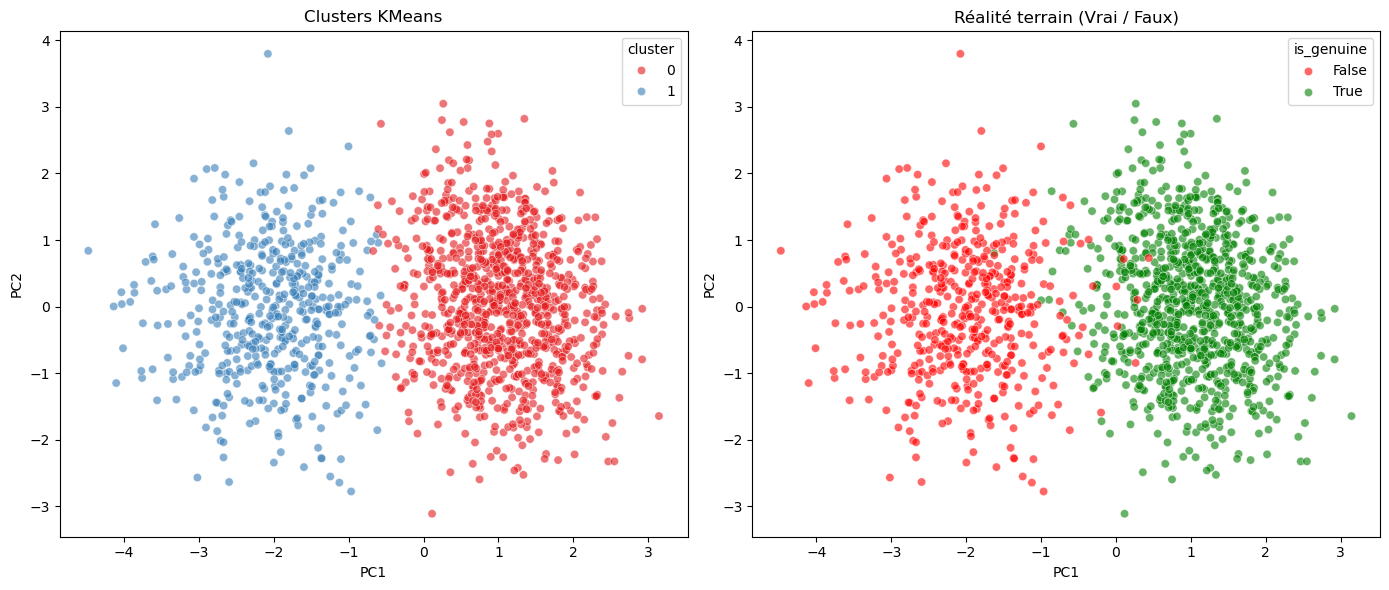

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique clusters
sns.scatterplot(
    data=df_kmeans,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set1",
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title("Clusters KMeans")

# Graphique réalité terrain
sns.scatterplot(
    data=df_kmeans,
    x="PC1",
    y="PC2",
    hue="is_genuine",
    palette={True: "green", False: "red"},
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Réalité terrain (Vrai / Faux)")

plt.tight_layout()
plt.show()


<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 5 – Modélisation supervisée</h2>
</div>


L’objectif de cette étape est de construire et d’évaluer plusieurs modèles de classification afin de prédire si un billet est authentique ou contrefait à partir de ses caractéristiques géométriques.

Les modèles testés sont :
- la régression logistique,
- le K-nearest neighbors (KNN),
- la Random Forest.

Ces modèles seront comparés à l’aide de métriques adaptées (matrice de confusion, accuracy, précision, rappel, F1-score et courbe ROC), dans l’objectif d’identifier le modèle le plus performant pour détecter les faux billets.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">5.1 Prétraitement : standardisation des variables</h3>
</div>

Les variables géométriques utilisées pour la classification n’ont pas toutes la même échelle
(longueur, diagonale, marges, etc.).

La standardisation (centrage-réduction) permet :
- de mettre toutes les variables sur une échelle comparable,
- d’améliorer la stabilité numérique des modèles,
- d’éviter qu’une variable domine les autres uniquement par son ordre de grandeur.

Cette étape est indispensable pour les modèles sensibles à l’échelle des données,
comme la régression logistique et le KNN.


In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardisation effectuée.")


Standardisation effectuée.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">5.2 – Régression logistique</h3>
</div>

>La régression logistique est un modèle de classification supervisée qui permet d’estimer la probabilité qu’un billet soit authentique (`is_genuine = 1`) à partir de ses caractéristiques géométriques.
>
>Ce modèle est utilisé ici comme modèle de référence (baseline) :
>- il est simple et interprétable,
>- il permet de disposer d’un point de comparaison pour les modèles plus complexes,
>- il fournit des probabilités de prédiction exploitables.

### 5.2.1 Entraînement du modèle

In [97]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    solver="liblinear",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

print("Régression logistique entraînée.")


Régression logistique entraînée.


### 5.2.2 Prédictions sur le jeu de test

Une fois le modèle entraîné sur le jeu d’entraînement, nous réalisons les prédictions sur le jeu de test afin d’évaluer ses performances sur des données non vues.

In [100]:
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Prédictions effectuées.")


Prédictions effectuées.


### 5.2.3 Évaluation des performances

Les performances du modèle sont évaluées à l’aide de :
- la matrice de confusion,
- l’accuracy,
- la précision, le rappel et le F1-score.

Une attention particulière est portée au rappel de la classe "faux billet",
car l’objectif opérationnel est de détecter un maximum de contrefaçons.


Accuracy : 0.9863481228668942


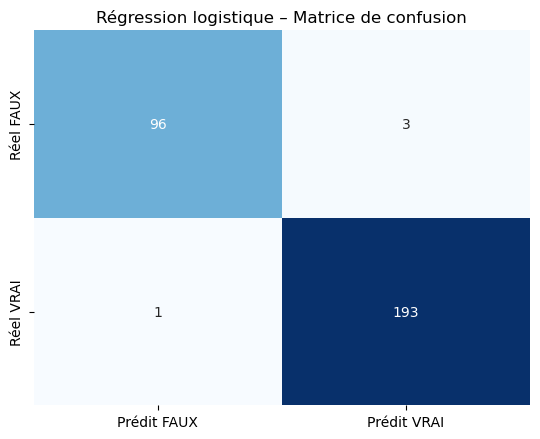


Rapport de classification :
              precision    recall  f1-score   support

        FAUX       0.99      0.97      0.98        99
        VRAI       0.98      0.99      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.98       293
weighted avg       0.99      0.99      0.99       293



In [103]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1) Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred_log))

# 2) Matrice de confusion (ordre explicite : False = faux billet, True = vrai billet)
labels = [False, True]
cm = confusion_matrix(y_test, y_pred_log, labels=labels)

# Affichage heatmap
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Prédit FAUX", "Prédit VRAI"],
    yticklabels=["Réel FAUX", "Réel VRAI"]
)
plt.title("Régression logistique – Matrice de confusion")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 3) Rapport de classification (avec labels explicites)
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_log, labels=labels, target_names=["FAUX", "VRAI"]))


### 5.2.4 – Interprétation des résultats de la régression logistique

La régression logistique obtient une **accuracy** de **98,6 %** sur le **jeu de test**, ce qui indique une excellente capacité globale à distinguer les vrais billets des faux billets.

L’analyse de la matrice de confusion montre :

- **96 faux billets correctement détectés**,
- **3 faux billets classés à tort comme vrais billets** (faux négatifs),
- **193 vrais billets correctement identifiés**,
- **1 vrai billet classé à tort comme faux billet** (faux positif).

Du point de vue opérationnel, le rappel pour la classe *faux billet* est de **97 %**, ce qui signifie que le modèle détecte la grande majorité des contrefaçons.

Ce critère est particulièrement important dans le contexte de lutte contre le faux-monnayage, où l’objectif est de limiter au maximum le nombre de faux billets non détectés.

La précision élevée pour les deux classes indique également que les erreurs de classification restent très limitées, aussi bien pour les faux billets que pour les billets authentiques.

En conclusion, la régression logistique constitue un **modèle de référence très performant**, simple à interpréter et offrant déjà un excellent compromis entre performance et robustesse. 

Elle servira de baseline pour la comparaison avec les autres modèles de classification.

<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">5.3 – Courbe ROC et AUC (Régression logistique)</h3>
</div>

La courbe ROC (Receiver Operating Characteristic) permet d’évaluer la capacité d’un modèle de classification à discriminer les classes pour tous les seuils
de décision possibles.

Elle représente :
- en abscisse : le taux de faux positifs (1 - spécificité),
- en ordonnée : le taux de vrais positifs (rappel).

L’AUC (Area Under the Curve) mesure la performance globale du modèle :
- AUC = 0.5 : modèle aléatoire,
- AUC = 1.0 : modèle parfait.

Plus l’AUC est proche de 1, meilleure est la capacité de discrimination du modèle.

In [108]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calcul des valeurs ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

# Calcul de l'AUC
auc_log = roc_auc_score(y_test, y_proba_log)

print("AUC (Régression logistique) :", auc_log)


AUC (Régression logistique) : 0.9996355305633656


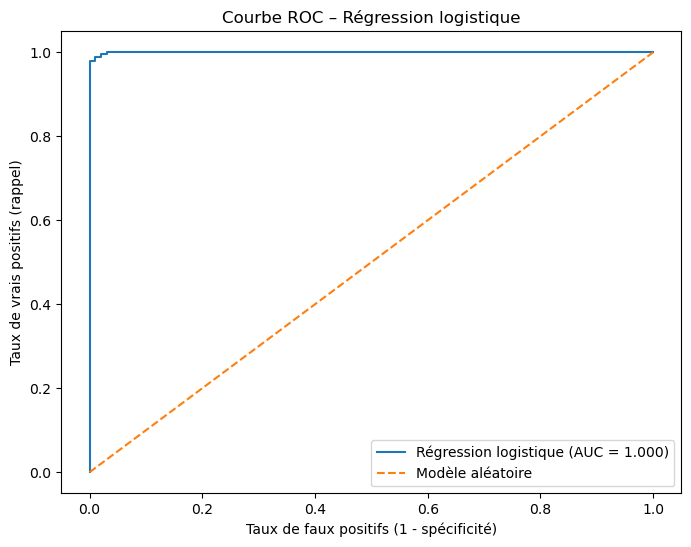

In [109]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Régression logistique (AUC = {auc_log:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modèle aléatoire")

plt.xlabel("Taux de faux positifs (1 - spécificité)")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.title("Courbe ROC – Régression logistique")
plt.legend()
plt.show()


### Interprétation de la courbe ROC

La courbe ROC de la régression logistique est très proche du coin supérieur gauche, ce qui indique une excellente capacité de discrimination entre les vrais billets et les faux billets.

L’aire sous la courbe (AUC) est égale à **0.9996**, soit une valeur très proche de 1. 

Cela signifie que le modèle parvient à distinguer presque parfaitement les deux classes, quel que soit le seuil de décision retenu.

Ces résultats confirment les performances observées à partir de la matrice de confusion et montrent que la régression logistique constitue un modèle de référence particulièrement robuste dans ce contexte.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">5.4 – KNN (K-Nearest Neighbors)</h3>
</div>

Le **KNN** est un algorithme de classification non paramétrique.
    
Il classe une observation en fonction de la classe majoritaire parmi ses k plus proches voisins dans l’espace des variables.

Ce modèle est :
- intuitif,
- sensible à l’échelle des variables (d’où la standardisation préalable),
- dépendant du choix du nombre de voisins k.

L’objectif de cette étape est de tester différentes valeurs de k afin d’identifier celle offrant le meilleur compromis entre performance et stabilité du modèle.

### 5.4.1 Recherche du meilleur k

On teste plusieurs valeurs de k et on observe l’accuracy sur le jeu de test.

In [115]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_knn)
    accuracies.append(acc)

# Résumé des résultats
for k, acc in zip(k_values, accuracies):
    print(f"k = {k:2d} | accuracy = {acc:.4f}")


k =  1 | accuracy = 0.9761
k =  2 | accuracy = 0.9829
k =  3 | accuracy = 0.9829
k =  4 | accuracy = 0.9829
k =  5 | accuracy = 0.9829
k =  6 | accuracy = 0.9898
k =  7 | accuracy = 0.9863
k =  8 | accuracy = 0.9863
k =  9 | accuracy = 0.9863
k = 10 | accuracy = 0.9863
k = 11 | accuracy = 0.9863
k = 12 | accuracy = 0.9863
k = 13 | accuracy = 0.9863
k = 14 | accuracy = 0.9863
k = 15 | accuracy = 0.9863
k = 16 | accuracy = 0.9863
k = 17 | accuracy = 0.9863
k = 18 | accuracy = 0.9863
k = 19 | accuracy = 0.9863
k = 20 | accuracy = 0.9863


### 5.4.2 Visualisation accuracy en fonction de k

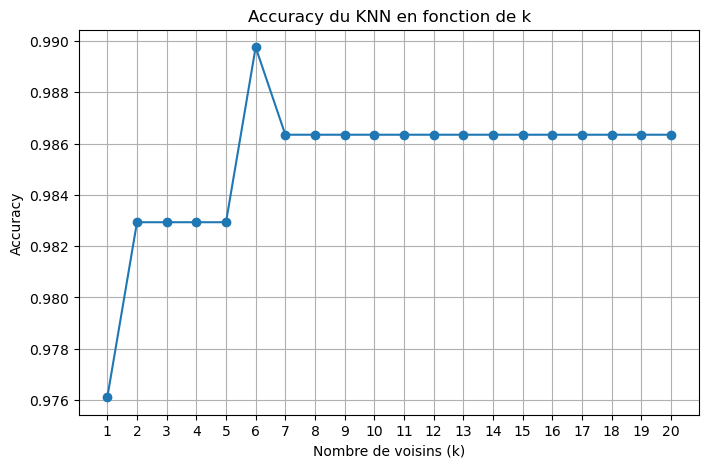

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Nombre de voisins (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy du KNN en fonction de k")
plt.xticks(k_values)
plt.grid(True)
plt.show()


### 5.4.3 Choix de k

L’analyse de l’accuracy en fonction du nombre de voisins montre une amélioration progressive des performances lorsque k augmente, jusqu’à atteindre un maximum pour **k = 6**.

Au-delà de cette valeur, l’accuracy se stabilise à un niveau légèrement inférieur, ce qui suggère un lissage excessif de la frontière de décision.

La valeur **k = 6** est retenue car elle offre le meilleur compromis entre performance et stabilité du modèle.


### 5.4.4 Entraînement du KNN optimal

In [121]:
best_k = 6  

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_knn_best = knn_best.predict(X_test_scaled)
y_proba_knn_best = knn_best.predict_proba(X_test_scaled)[:, 1]

print(f"KNN entraîné avec k = {best_k}")


KNN entraîné avec k = 6


### 5.4.5 Évaluation du KNN

Nous évaluons les performances du KNN sélectionné à l’aide :
- de l’accuracy,
- de la matrice de confusion,
- du rapport de classification.

Ces résultats seront ensuite comparés à ceux de la régression logistique.

Accuracy : 0.9897610921501706


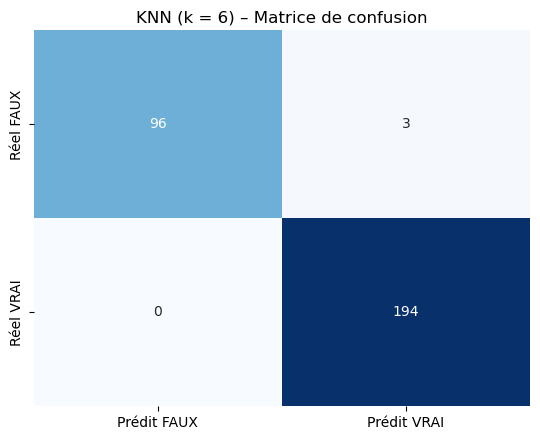


Rapport de classification :
              precision    recall  f1-score   support

        FAUX       1.00      0.97      0.98        99
        VRAI       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1) Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred_knn_best))  # ici y_pred_knn_best doit venir du KNN k=2

# 2) Matrice de confusion (ordre explicite : False = faux billet, True = vrai billet)
labels = [False, True]
cm = confusion_matrix(y_test, y_pred_knn_best, labels=labels)

# Affichage heatmap
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Prédit FAUX", "Prédit VRAI"],
    yticklabels=["Réel FAUX", "Réel VRAI"]
)
plt.title("KNN (k = 6) – Matrice de confusion")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 3) Rapport de classification
print("\nRapport de classification :")
print(classification_report(
    y_test,
    y_pred_knn_best,
    labels=labels,
    target_names=["FAUX", "VRAI"]
))


### 5.4.6 – Interprétation des résultats du KNN

Le modèle KNN avec **k = 6** obtient une accuracy de **98,98 %**, ce qui traduit une excellente performance globale de classification.

L’analyse de la matrice de confusion montre que :
- **96 faux billets sont correctement détectés**,
- **3 faux billets sont classés à tort comme vrais billets** (faux négatifs),
- **tous les vrais billets sont correctement identifiés** (aucun faux positif).

Le rappel pour la classe **FAUX** est de **97 %**, indiquant que la grande majorité des contrefaçons sont détectées.

En contrepartie, le modèle ne génère aucun faux positif, ce qui signifie qu’aucun billet authentique n’est incorrectement signalé comme faux.

Ces résultats illustrent un compromis intéressant entre détection des faux billets et limitation des erreurs sur les billets authentiques.

Le KNN offre d’excellentes performances, mais repose sur une logique de proximité 
entre observations, ce qui le rend moins interprétable et plus dépendan 
de la structure exacte des données que la régression logistique.

Nous testons désormais un modèle d’ensemble plus robuste et plus flexible : la **Random Forest**, afin d’évaluer si elle permet d’améliorer encore les performances tout en offrant une meilleure stabilité.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">5.5 – Random Forest</h3>
</div>

La **Random Forest** est un algorithme de classification basé sur un ensemble d’arbres de décision construits sur des sous-échantillons des données
et des variables.

Ce modèle présente plusieurs avantages :
- il est robuste au bruit,
- il capte des relations non linéaires,
- il limite le sur-apprentissage grâce à l’agrégation des arbres,
- il fournit une mesure de l’importance des variables.

L’objectif de cette étape est d’entraîner un modèle Random Forest, d’évaluer ses performances et de le comparer aux modèles précédents.


### 5.5.1 Entraînement du modèle Random Forest

In [131]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest entraînée.")


Random Forest entraînée.


### 5.5.2 Prédictions sur le jeu de test

Le modèle entraîné est utilisé pour prédire la nature des billets sur le jeu de test, afin d’évaluer ses performances sur des données non vues.

In [134]:
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Prédictions Random Forest effectuées.")


Prédictions Random Forest effectuées.


### 5.5.3 – Évaluation des performances

Les performances du modèle Random Forest sont évaluées à l’aide :
- de l’accuracy,
- de la matrice de confusion,
- du rapport de classification.

Ces résultats permettront de comparer ce modèle aux approches précédentes.

Accuracy : 0.9897610921501706


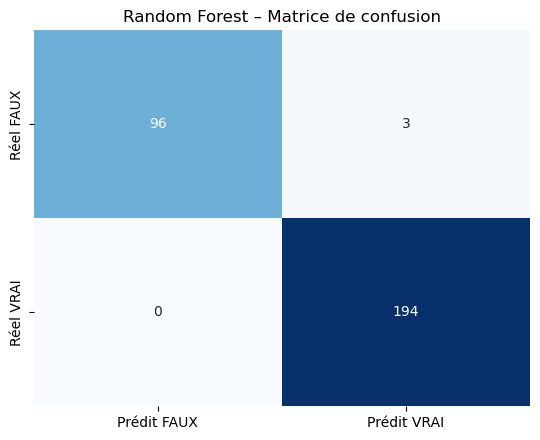


Rapport de classification :
              precision    recall  f1-score   support

        FAUX       1.00      0.97      0.98        99
        VRAI       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



In [136]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1) Accuracy
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

# 2) Matrice de confusion (ordre explicite : False = faux billet, True = vrai billet)
labels = [False, True]
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

# Affichage heatmap
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Prédit FAUX", "Prédit VRAI"],
    yticklabels=["Réel FAUX", "Réel VRAI"]
)
plt.title("Random Forest – Matrice de confusion")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

# 3) Rapport de classification
print("\nRapport de classification :")
print(classification_report(
    y_test,
    y_pred_rf,
    labels=labels,
    target_names=["FAUX", "VRAI"]
))



### 5.5.4 – Visualisation de l'importance des variables

La Random Forest permet d’estimer l’importance relative des variables dans la prise de décision du modèle.

Cette analyse aide à comprendre quelles caractéristiques géométriques contribuent le plus à la distinction entre vrais et faux billets.


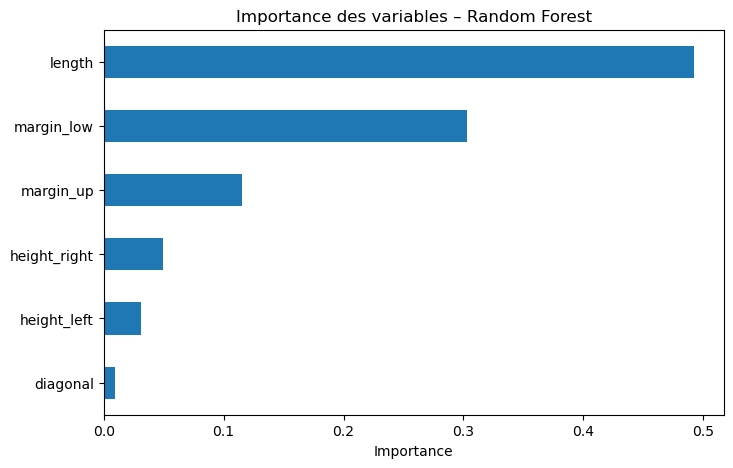

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Importance des variables – Random Forest")
plt.show()


### Interprétation de l’importance des variables

Le graphique met en évidence une hiérarchie claire dans la contribution des variables à la décision du modèle :

- **La variable *length*** apparaît comme la plus discriminante, avec une importance d’environ 50 %.  
  Cela signifie que la longueur du billet constitue le critère principal utilisé par la Random Forest pour distinguer les vrais des faux billets.

- **La variable *margin_low*** arrive en deuxième position (≈ 30 %), indiquant que la marge inférieure joue également un rôle déterminant dans la détection des contrefaçons.

- **La variable *margin_up*** contribue de manière plus modérée (≈ 10 %).

- Les variables **height_right**, **height_left** et surtout **diagonal** ont un impact beaucoup plus faible sur la décision finale.

Cette hiérarchie montre que les différences entre vrais et faux billets sont principalement liées à des variations de dimensions longitudinales et de marges, tandis que la diagonale semble peu discriminante dans ce jeu de données.

Ces résultats renforcent l’idée que certaines caractéristiques géométriques sont nettement plus structurantes que d’autres dans la détection des faux billets.


### 5.5.5 – Interprétation des résultats de la Random Forest

La Random Forest atteint une accuracy de **98,98 %**, comparable à celle obtenue avec le modèle KNN et légèrement supérieure à celle de la régression logistique.

L’analyse de la matrice de confusion montre que :
- **96 faux billets sont correctement détectés**,
- **3 faux billets sont classés à tort comme vrais billets** (faux négatifs),
- **tous les vrais billets sont correctement identifiés** (aucun faux positif).

Le rappel pour la classe **FAUX** est de **97 %**, indiquant que la grande majorité des contrefaçons sont détectées, mais que quelques faux billets peuvent encore échapper au modèle.

Les performances très proches de celles du KNN confirment que les relations entre les variables sont bien capturées par les modèles non linéaires.

La Random Forest présente toutefois l’avantage supplémentaire de fournir une mesure de l’importance des variables, facilitant l’interprétation globale
du modèle.


L’analyse des importances montre que la variable *length* est de loin la plus déterminante dans la classification, suivie par *margin_low*. 
Ces résultats suggèrent que les écarts les plus significatifs entre vrais et faux billets concernent principalement la longueur et la marge inférieure du billet, ce qui confirme l’intérêt d’un modèle capable de capturer des interactions non linéaires entre ces dimensions.


<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 6 – Comparaison des modèles et choix du modèle final
</div>


Après avoir entraîné plusieurs modèles de classification, l’objectif de cette étape est de comparer leurs performances afin de sélectionner le modèle le plus pertinent pour une mise en production.

La comparaison porte à la fois sur :
- les performances globales de classification,
- la capacité à détecter les faux billets,
- l’interprétabilité du modèle,
- la robustesse et la facilité de déploiement.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">6.1 Récapitulatif des performances des modèles</h3>
</div>

### 6.1 – Récapitulatif des performances des modèles

Trois modèles supervisés ont été entraînés et évalués sur le même jeu de test :

- **Régression logistique**
  - Accuracy ≈ **98,6 %**
  - 3 faux billets non détectés
  - 1 faux positif
  - Modèle simple et interprétable

- **KNN (k = 6)**
  - Accuracy ≈ **99,0 %**
  - 3 faux billets non détectés
  - 0 faux positif
  - Modèle basé sur la proximité des observations

- **Random Forest**
  - Accuracy ≈ **99,0 %**
  - 3 faux billets non détectés
  - 0 faux positif
  - Modèle robuste capturant des relations non linéaires

Les trois modèles présentent donc des performances très élevées
et relativement proches, ce qui confirme la bonne séparabilité des données.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">6.2 – Tableau comparatif des modèles</h3>
</div>

Le tableau ci-dessous synthétise les performances des modèles à l’aide des principales métriques d’évaluation, en se concentrant sur la classe **FAUX** (faux billets), ainsi que sur des critères qualitatifs importants
pour une mise en production.

| Modèle | Accuracy | Precision (FAUX) | Recall (FAUX) | F1-score (FAUX) | Interprétabilité | Robustesse |
|------|----------|------------------|---------------|-----------------|------------------|------------|
| Régression logistique | 98,6 % | 0,99 | 0,97 | 0,98 | Élevée | Élevée |
| KNN (k = 6) | 99,0 % | 1,00 | 0,97 | 0,98 | Faible | Moyenne |
| Random Forest | 99,0 % | 1,00 | 0,97 | 0,98 | Moyenne | Élevée |


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">6.3 Choix du modèle final</h3>
</div>

Les trois modèles supervisés testés présentent des performances très élevées
et relativement proches, avec des écarts marginaux sur les métriques de classification.

La régression logistique obtient une accuracy légèrement inférieure
à celles du KNN et de la Random Forest, mais cet écart reste faible
(≈ 0,4 point) et ne justifie pas, à lui seul, le recours à un modèle plus complexe.

En pratique, un modèle plus sophistiqué doit apporter un gain de performance
significatif (de l’ordre de 3 à 5 points) pour compenser :
- une interprétabilité plus faible,
- une complexité de mise en œuvre plus élevée,
- et un coût de maintenance potentiellement supérieur.

Dans ce contexte, la **régression logistique** présente plusieurs avantages déterminants :
- une excellente interprétabilité, grâce à une règle de décision globale claire ;
- une bonne robustesse face aux variations des données ;
- un coût de calcul faible et une mise en production simple ;
- des performances déjà très élevées sur la détection des faux billets.

En conséquence, la **régression logistique est retenue comme modèle final**
pour la mise en production du système de détection des faux billets,
car elle offre le meilleur compromis entre performance, explicabilité
et contraintes opérationnelles.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">6.4 – Cohérence avec l’analyse non supervisée
</h3>
</div>

L’analyse non supervisée par KMeans a montré que les billets se regroupent naturellement en deux clusters correspondant majoritairement aux vrais et aux faux billets.

Cette structuration naturelle des données explique les excellentes performances obtenues par les modèles supervisés et renforce la confiance dans le modèle retenu.


<div style="background-color: RGB(51,165,182);">
  <h2 style="margin: auto; padding: 20px; color: white;">Étape 7 – Mise en production du modèle de détection des faux billets
</div>

L’objectif de cette étape est de rendre le modèle sélectionné exploitable
en dehors du notebook d’entraînement.

Cela implique :
- la sauvegarde du modèle final,
- l’inclusion des étapes de préprocessing nécessaires,
- la possibilité d’appliquer le modèle à de nouvelles données,
  comme le fichier `billets_production.csv`.

Cette étape marque la transition entre l’analyse exploratoire
et une utilisation opérationnelle du modèle.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">7.1 – Création du pipeline final
</h3>
</div>

Afin de garantir la cohérence entre l’entraînement et l’utilisation du modèle
en production, nous utilisons un **pipeline scikit-learn**.

Ce pipeline inclut :
- la standardisation des variables (`StandardScaler`),
- le modèle de régression logistique retenu.

Ainsi, les transformations appliquées aux nouvelles données
seront strictement identiques à celles utilisées lors de l’entraînement.

In [156]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="liblinear", random_state=42)
)

pipeline_lr.fit(X_train, y_train)

print("Pipeline de régression logistique entraîné.")


Pipeline de régression logistique entraîné.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">7.2 – Vérification des performances du pipeline
</h3>
</div>

Avant la sauvegarde définitive, nous vérifions que le pipeline
reproduit bien les performances observées précédemment
sur le jeu de test.

In [159]:
from sklearn.metrics import accuracy_score

y_pred_pipeline = pipeline_lr.predict(X_test)
print("Accuracy du pipeline :", accuracy_score(y_test, y_pred_pipeline))


Accuracy du pipeline : 0.9863481228668942


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">7.3 – Sauvegarde du modèle final
</h3>
</div>

Le pipeline est sauvegardé à l’aide de la librairie `joblib`.
Ce fichier unique contient à la fois :
- le modèle de régression logistique,
- les étapes de préprocessing.

Il pourra ainsi être rechargé ultérieurement
pour effectuer des prédictions sur de nouvelles données.

In [162]:
import joblib

joblib.dump(pipeline_lr, "pipeline_detection_faux_billets.pkl")

print("Pipeline sauvegardé sous le nom : pipeline_detection_faux_billets.pkl")


Pipeline sauvegardé sous le nom : pipeline_detection_faux_billets.pkl


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">7.4 – Prédiction sur de nouvelles données
</h3>
</div>

Nous chargeons le pipeline sauvegardé et l’appliquons
à un nouveau jeu de données afin de démontrer
son utilisation en condition réelle.


In [165]:
import pandas as pd
import joblib

# Chargement du fichier de production
df_prod = pd.read_csv("billets_production.csv")

# Variables utilisées par le modèle (même ordre que lors de l'entraînement)
features = [
    "diagonal",
    "height_left",
    "height_right",
    "margin_up",
    "margin_low",
    "length"
]

X_prod = df_prod[features].copy()

# Chargement du pipeline sauvegardé
pipeline_loaded = joblib.load("pipeline_detection_faux_billets.pkl")

# Prédictions
y_pred_prod = pipeline_loaded.predict(X_prod)
y_proba_prod = pipeline_loaded.predict_proba(X_prod)

# Ajout des résultats au dataframe (en conservant l'id)
df_prod["prediction"] = y_pred_prod
df_prod["prediction_label"] = df_prod["prediction"].map(
    {True: "VRAI", False: "FAUX"}
)

df_prod["proba_vrai"] = y_proba_prod[:, 1]
df_prod["proba_faux"] = y_proba_prod[:, 0]

display(df_prod)


,diagonal,height_left,height_right,margin_low,margin_up,length,id,prediction,prediction_label,proba_vrai,proba_faux
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1,False,FAUX,0.001633,0.998367
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2,False,FAUX,0.000178,0.999822
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3,False,FAUX,0.000358,0.999642
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4,True,VRAI,0.970582,0.029418
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5,True,VRAI,0.999801,0.000199


Le pipeline chargé a été appliqué au fichier `billets_production.csv`,
contenant de nouveaux billets à analyser.

Pour chaque billet, le modèle fournit :
- une prédiction binaire (**VRAI** ou **FAUX**),
- ainsi qu’un degré de confiance associé, via les probabilités estimées.

Les résultats montrent que :
- certains billets sont prédits comme faux avec une probabilité très élevée
  (supérieure à 99 %), ce qui traduit une forte certitude du modèle ;
- d’autres billets sont prédits comme authentiques avec une probabilité
  également très élevée.

La présence des probabilités permet d’aller au-delà d’une simple décision binaire
et offre une aide à la décision précieuse, notamment pour définir des seuils
de contrôle ou prioriser les vérifications manuelles.


<div style="border: 1px solid RGB(51,165,182); padding: 15px;">
  <h3 style="color: RGB(51,165,182); margin: 0;">7.5 – Conclusion de la mise en production
</h3>
</div>

Le modèle final a été sauvegardé sous forme de pipeline,
incluant les étapes de préprocessing nécessaires.

Il peut désormais être utilisé pour prédire automatiquement
la nature de nouveaux billets à partir de leurs caractéristiques
géométriques, sans nécessiter de retraitement manuel des données.

Cette étape conclut le projet en reliant l’analyse de données
à une application opérationnelle concrète.
